In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("spotify_yt.csv")

In [21]:
print("Adatkeret információi")
df.info()

print("\nAdatkeret statisztikái")
display(df.describe(include="all"))

Adatkeret információi
<class 'pandas.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            20718 non-null  str    
 1   Url_spotify       20718 non-null  str    
 2   Track             20718 non-null  str    
 3   Album             20718 non-null  str    
 4   Album_type        20718 non-null  str    
 5   Uri               20718 non-null  str    
 6   Danceability      20708 non-null  float64
 7   Energy            20609 non-null  float64
 8   Key               20716 non-null  float64
 9   Loudness          20447 non-null  float64
 10  Speechiness       20716 non-null  float64
 11  Acousticness      20633 non-null  float64
 12  Instrumentalness  20664 non-null  float64
 13  Liveness          20716 non-null  float64
 14  Valence           20716 non-null  float64
 15  Tempo             20716 non-null  float64
 16  Duration_ms       20716 non-n

,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
count,20718,20718,20718,20718,20718,20718,20708.000000,20609.000000,20716.000000,20447.000000,...,20248,20248,20248,2.024800e+04,2.017700e+04,2.014900e+04,19842,20248,20248,2.014200e+04
unique,2079,2079,17841,11937,3,18862,NaN,NaN,NaN,NaN,...,18154,18146,6714,NaN,NaN,NaN,17395,2,2,NaN
top,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,El Ultimo Adiós - Varios Artistas Version,Greatest Hits,album,spotify:track:0tzixmHNQfE6S6SirSToxW,NaN,NaN,NaN,NaN,...,https://www.youtube.com/watch?v=GqOvxbFLwjY,Color Esperanza 2020 - Various Artists (Offici...,T-Series,NaN,NaN,NaN,,True,True,NaN
freq,10,10,24,30,14926,24,NaN,NaN,NaN,NaN,...,18,18,238,NaN,NaN,NaN,114,14140,15723,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.619764,0.635299,5.300348,-7.673321,...,NaN,NaN,NaN,9.393782e+07,6.633411e+05,2.751899e+04,NaN,NaN,NaN,1.359422e+08
std,NaN,NaN,NaN,NaN,NaN,NaN,0.165275,0.214133,3.576449,4.635906,...,NaN,NaN,NaN,2.746443e+08,1.789324e+06,1.932347e+05,NaN,NaN,NaN,2.441321e+08
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000020,0.000000,-46.251000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,6.574000e+03
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.518750,0.507000,2.000000,-8.860500,...,NaN,NaN,NaN,1.826002e+06,2.158100e+04,5.090000e+02,NaN,NaN,NaN,1.767486e+07
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.637000,0.666000,5.000000,-6.536000,...,NaN,NaN,NaN,1.450110e+07,1.244810e+05,3.277000e+03,NaN,NaN,NaN,4.968298e+07
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.740000,0.798000,8.000000,-4.930500,...,NaN,NaN,NaN,7.039975e+07,5.221480e+05,1.436000e+04,NaN,NaN,NaN,1.383581e+08


In [22]:
print(df.isnull().sum())

Artist                0
Url_spotify           0
Track                 0
Album                 0
Album_type            0
Uri                   0
Danceability         10
Energy              109
Key                   2
Loudness            271
Speechiness           2
Acousticness         85
Instrumentalness     54
Liveness              2
Valence               2
Tempo                 2
Duration_ms           2
Url_youtube         470
Title               470
Channel             470
Views               470
Likes               541
Comments            569
Description         876
Licensed            470
official_video      470
Stream              576
dtype: int64


In [23]:
cols_to_fill = ["Loudness", "Acousticness", "Instrumentalness", "Energy", "Danceability"]

for col in cols_to_fill:
    df[col] = df.groupby("Artist")[col].transform(lambda x: x.fillna(x.mean()))

print("Hiányzó értékek száma a feltöltés után:")
print(df[cols_to_fill].isnull().sum())

Hiányzó értékek száma a feltöltés után:
Loudness            0
Acousticness        0
Instrumentalness    0
Energy              0
Danceability        0
dtype: int64


In [24]:
cols_to_check = ["Speechiness", "Liveness", "Valence", "Tempo", "Key", "Duration_ms"]

null_rows = df[df[cols_to_check].isnull().any(axis=1)]
print("Eldobásra kerülő sorok száma:", len(null_rows))
display(null_rows.head())


df.dropna(subset=cols_to_check, inplace=True)


print("\nHiányzó értékek száma az eldobás után:")
print(df[cols_to_check].isnull().sum())

Eldobásra kerülő sorok száma: 2


,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
11890,Natasha Bedingfield,https://open.spotify.com/artist/7o95ZoZt5ZYn31...,These Words,Unwritten,album,spotify:track:6MFQeWtk7kxWGydnJB2y36,0.593222,0.663778,NaN,-6.277444,...,https://www.youtube.com/watch?v=e5RuGj0g1tk,Natasha Bedingfield - These Words (Official Vi...,NBedingfieldVEVO,21655597.0,165220.0,7780.0,"Natasha Bedingfield - These Words (I Love You,...",True,True,110442210.0
13843,White Noise for Babies,https://open.spotify.com/artist/4ZfEELHfyKd4od...,Rain in the Early Morning,Soothing Rain for Background Sounds and Natura...,album,spotify:track:4juc1w1fGFn8CxKp8gGThc,0.080233,0.077183,NaN,-31.195778,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,145339552.0



Hiányzó értékek száma az eldobás után:
Speechiness    0
Liveness       0
Valence        0
Tempo          0
Key            0
Duration_ms    0
dtype: int64


In [25]:
print("Eredeti adattípusok")
print(df.dtypes)

int_cols = ["Duration_ms", "Key", "Views", "Likes", "Comments", "Stream"]
bool_cols = ["Licensed", "official_video"]

df[int_cols] = df[int_cols].fillna(-1).astype(np.int64)

df[bool_cols] = df[bool_cols].fillna(False).astype(bool)

print("\nMódosított adattípusok")
print(df.dtypes)

Eredeti adattípusok
Artist                  str
Url_spotify             str
Track                   str
Album                   str
Album_type              str
Uri                     str
Danceability        float64
Energy              float64
Key                 float64
Loudness            float64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo               float64
Duration_ms         float64
Url_youtube             str
Title                   str
Channel                 str
Views               float64
Likes               float64
Comments            float64
Description             str
Licensed             object
official_video       object
Stream              float64
dtype: object

Módosított adattípusok
Artist                  str
Url_spotify             str
Track                   str
Album                   str
Album_type              str
Uri                     str
Danceability      

In [26]:
df = df[df["Stream"] != -1]
df.drop(columns=["Url_spotify", "Uri"], inplace=True)

In [27]:
df.to_csv("spotify_yt_cleaned.csv", index=False)

In [28]:
youtube_video_count = df["Url_youtube"].notna().sum()
print(f"{youtube_video_count} zeneszámhoz található Youtube videó.")

19691 zeneszámhoz található Youtube videó.


In [29]:
top10_danceable = df.groupby("Artist")["Danceability"].mean().sort_values(ascending=False).head(10)
print("A 10 leginkább táncolható előadó:")
display(top10_danceable)

A 10 leginkább táncolható előadó:


Artist
Saweetie                  0.885800
Three 6 Mafia             0.866556
Young Dolph               0.862900
Megan Thee Stallion       0.860500
Dave                      0.859100
Plan B                    0.858286
Ovy On The Drums          0.854600
Ski Mask The Slump God    0.852800
Migos                     0.851100
Blueface                  0.850200
Name: Danceability, dtype: float64

A 10 legtöbbet streamelt előadó:


Artist
Post Malone        15251263853
Ed Sheeran         14394881557
Dua Lipa           13408076274
XXXTENTACION       13224351699
The Weeknd         13031973376
Justin Bieber      12097767422
Imagine Dragons    11858310928
Coldplay           11778478236
Khalid             11386839915
Bruno Mars         10897862950
Name: Stream, dtype: int64


A 10 legtöbbet nézett előadó:


Artist
Ed Sheeran                 15460207769
CoComelon                  14601671211
Katy Perry                 13120632075
Charlie Puth               12167594191
Luis Fonsi                 11628113031
Justin Bieber              10991060236
Daddy Yankee               10871926842
Bruno Mars                 10240919227
Macklemore & Ryan Lewis    10122055560
Coldplay                    9997277884
Name: Views, dtype: int64

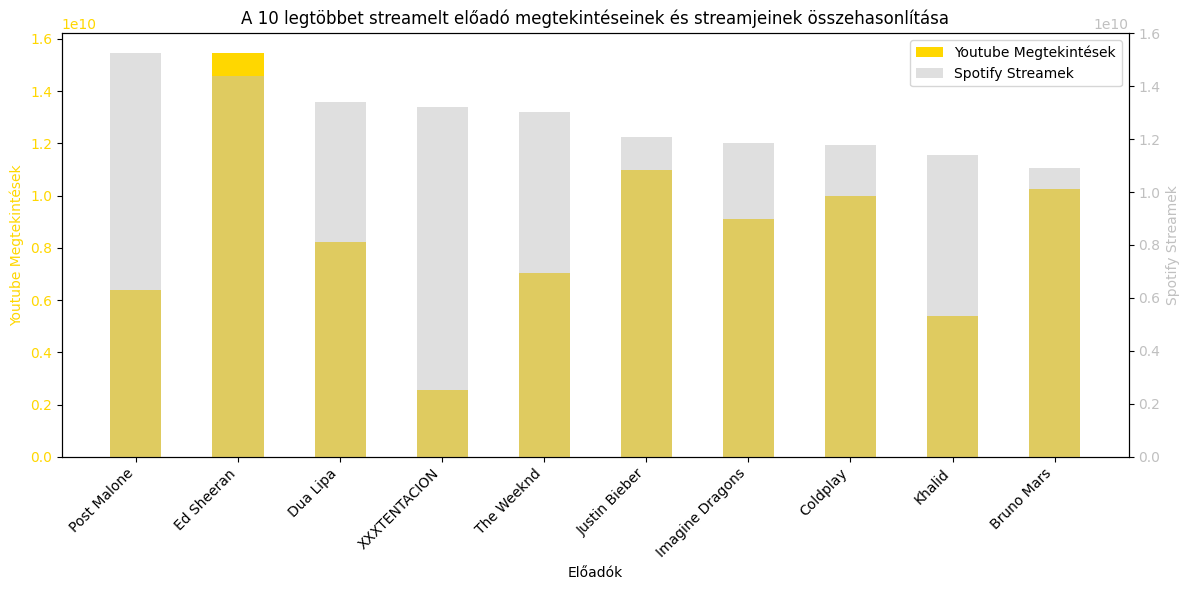

In [30]:
top10_streamed = df.groupby("Artist")["Stream"].sum().sort_values(ascending=False).head(10)
top10_viewed = df.groupby("Artist")["Views"].sum().sort_values(ascending=False).head(10)

print("A 10 legtöbbet streamelt előadó:")
display(top10_streamed)
print("\nA 10 legtöbbet nézett előadó:")
display(top10_viewed)

artists = top10_streamed.index
streams = top10_streamed.values
views = df.groupby("Artist")["Views"].sum()[artists].values

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(artists))
width = 0.5

ax1.bar(x, views, width, color="gold", label="Youtube Megtekintések")
ax1.set_xlabel("Előadók")
ax1.set_ylabel("Youtube Megtekintések", color="gold")
ax1.tick_params(axis="y", labelcolor="gold")
ax1.set_xticks(x)
ax1.set_xticklabels(artists, rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.bar(x, streams, width, color="silver", alpha=0.5, label="Spotify Streamek")
ax2.set_ylabel("Spotify Streamek", color="silver")
ax2.tick_params(axis="y", labelcolor="silver")

plt.title("A 10 legtöbbet streamelt előadó megtekintéseinek és streamjeinek összehasonlítása")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")

plt.tight_layout()
plt.show()

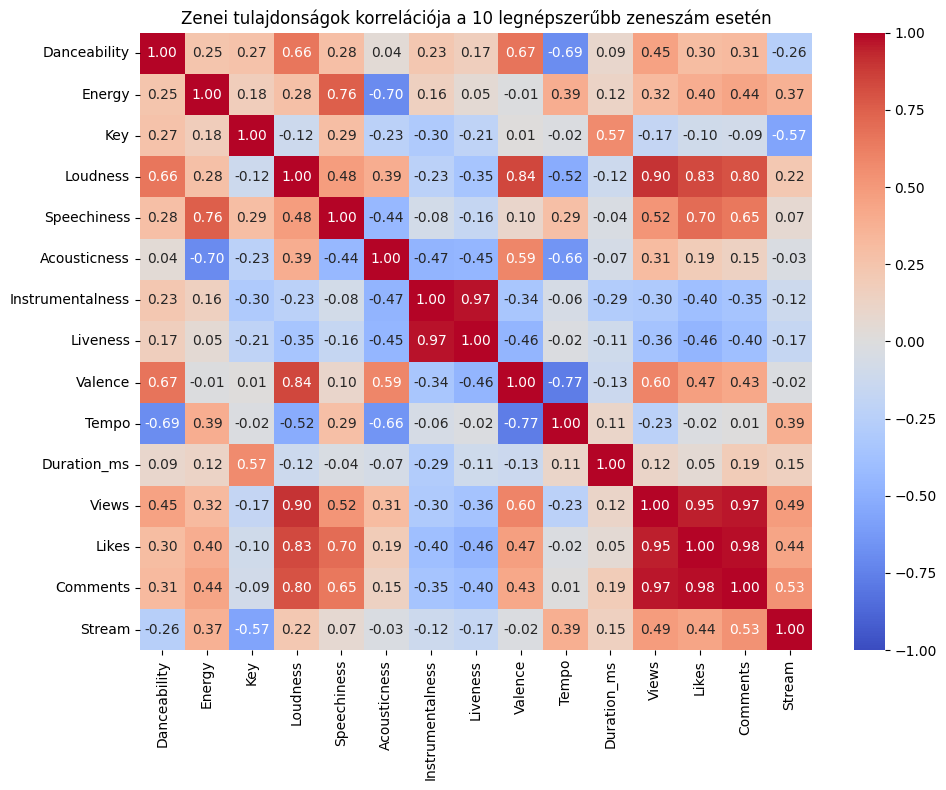

In [31]:
top10_tracks = df.sort_values(by="Stream", ascending=False).head(10)

numeric_cols = top10_tracks.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Zenei tulajdonságok korrelációja a 10 legnépszerűbb zeneszám esetén")
plt.tight_layout()
plt.show()

Legtöbb streamelés: Drake
Legtöbb megtekintés: Drake


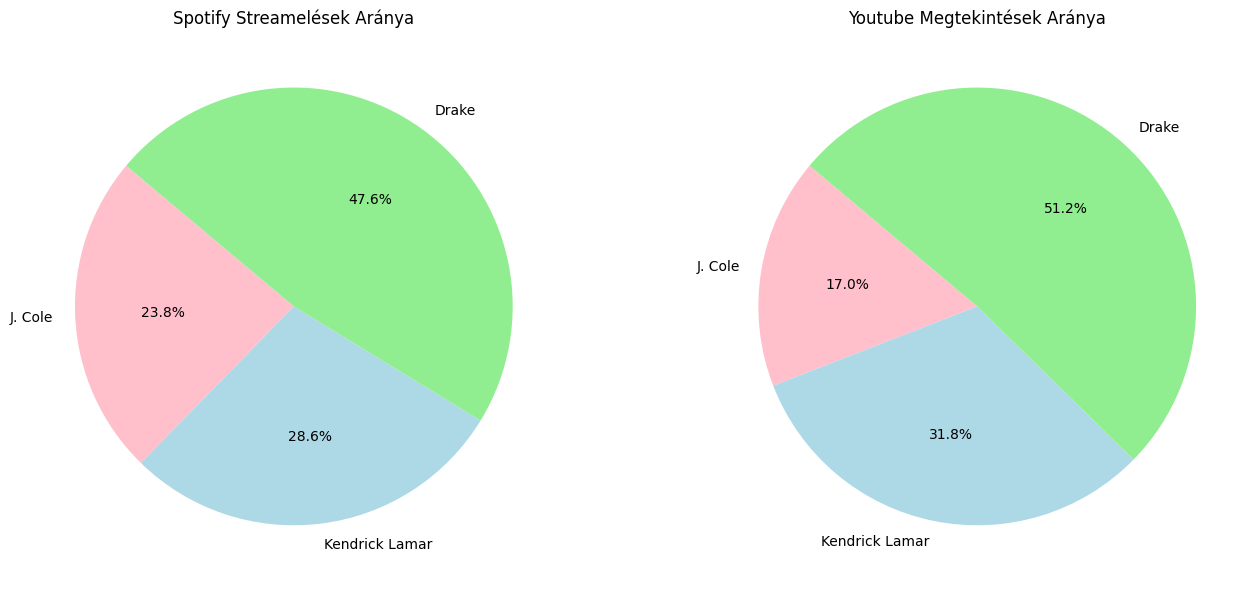

In [32]:
artists_to_compare = ["J. Cole", "Kendrick Lamar", "Drake"]
stats = {"Stream": [], "Views": []}

for artist in artists_to_compare:
    mask = df["Artist"].str.contains(artist, case=False, na=False) | df["Track"].str.contains(artist, case=False, na=False)
    filtered_df = df[mask].drop_duplicates(subset=["Track"])
    
    stats["Stream"].append(filtered_df["Stream"].sum())
    stats["Views"].append(filtered_df["Views"].sum())

winner_stream = artists_to_compare[np.argmax(stats["Stream"])]
winner_views = artists_to_compare[np.argmax(stats["Views"])]
print(f"Legtöbb streamelés: {winner_stream}")
print(f"Legtöbb megtekintés: {winner_views}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

fig.patch.set_facecolor("white") 

colors = ["pink","lightblue","lightgreen"]

ax1.pie(stats["Stream"], labels=artists_to_compare, autopct="%1.1f%%", startangle=140, colors=colors)
ax1.set_title("Spotify Streamelések Aránya")

ax2.pie(stats["Views"], labels=artists_to_compare, autopct="%1.1f%%", startangle=140, colors=colors)
ax2.set_title("Youtube Megtekintések Aránya")

plt.tight_layout()
plt.show()